# 预训练 `.npy` 与 EWS 训练原图

## `.npy` 切块（`EWS/data/pretrain/npy`）

从该目录中按文件名前缀各抽取 **10** 个样本：

- `globalwheat_*`（Global Wheat Detection 切块）
- `rgb_bonirob_*`（Sugar Beets / Bonirob RGB 切块）

数组约定：`float32`，形状 `(350, 350, 3)`，数值约 \([0,1]\)。

## EWS-Dataset 原图（`train`，无蒙层）

从 `EWS/data/EWS-Dataset/train` 读取 **仅 RGB PNG**（文件名不以 `_mask.png` 结尾，即纯原图、不与标注蒙层叠加），随机抽取 **10** 张，对整图计算：

- **亮度**：ITU-R BT.601 亮度 \(Y = 0.299R + 0.587G + 0.114B\)（\(R,G,B\in[0,1]\)），取全像素平均。
- **饱和度**：按 HSV 常用定义 \(S = \frac{\max(R,G,B)-\min(R,G,B)}{\max(R,G,B)}\)（分母为 0 时记 \(S=0\)），取全像素平均。

In [ ]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_npy_dir(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        d = p / "EWS" / "data" / "pretrain" / "npy"
        if d.is_dir():
            return d
    raise FileNotFoundError(
        "未找到 EWS/data/pretrain/npy。请在仓库根目录下启动内核，或修改 NPY_DIR。"
    )


NPY_DIR = find_npy_dir()
print("NPY_DIR:", NPY_DIR)

In [ ]:
N_PER_CLASS = 10
SEED = 42

paths_global = sorted(NPY_DIR.glob("globalwheat_*.npy"))
paths_boni = sorted(NPY_DIR.glob("rgb_bonirob_*.npy"))

rng = random.Random(SEED)


def pick_paths(paths: list[Path], n: int, rng: random.Random) -> list[Path]:
    if len(paths) < n:
        print(f"警告: 需要 {n} 个，但只有 {len(paths)} 个 —— 将全部使用。")
        return list(paths)
    return rng.sample(paths, n)


sel_gw = pick_paths(paths_global, N_PER_CLASS, rng)
sel_rb = pick_paths(paths_boni, N_PER_CLASS, rng)

print(f"globalwheat: {len(paths_global)} 个文件中抽取 {len(sel_gw)} 个")
print(f"rgb_bonirob: {len(paths_boni)} 个文件中抽取 {len(sel_rb)} 个")

In [ ]:
def load_rgb_npy(path: Path) -> np.ndarray:
    x = np.load(path, mmap_mode=None)
    if x.ndim != 3 or x.shape[2] != 3:
        raise ValueError(f"期望 (H,W,3)，得到 {x.shape}: {path.name}")
    return np.clip(x.astype(np.float32, copy=False), 0.0, 1.0)


def show_grid(rows: list[tuple[str, list[Path]]], ncols: int) -> None:
    nrows = len(rows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.4 * nrows))
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    for r, (title, plist) in enumerate(rows):
        for c in range(ncols):
            ax = axes[r, c]
            if c < len(plist):
                img = load_rgb_npy(plist[c])
                ax.imshow(img, vmin=0.0, vmax=1.0)
                ax.set_title(plist[c].stem[:28] + ("…" if len(plist[c].stem) > 28 else ""), fontsize=7)
            ax.axis("off")
        axes[r, 0].text(
            -0.35,
            0.5,
            title,
            transform=axes[r, 0].transAxes,
            fontsize=11,
            fontweight="bold",
            va="center",
            ha="right",
        )
    plt.tight_layout()
    plt.show()


show_grid(
    [
        ("globalwheat", sel_gw),
        ("rgb_bonirob", sel_rb),
    ],
    N_PER_CLASS,
)

### EWS-Dataset：`train` 原图（无蒙层）与亮度 / 饱和度

默认目录：`D:\Cursor\UNSW-COMP-9517\EWS\data\EWS-Dataset\train`；若不存在则从当前工作目录向上查找 `EWS/data/EWS-Dataset/train`。

EWS_TRAIN_DIR: D:\Cursor\UNSW-COMP-9517\EWS\data\EWS-Dataset\train


C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_9836\3613263401.py:68: UserWarning: Glyph 33945 (\N{CJK UNIFIED IDE

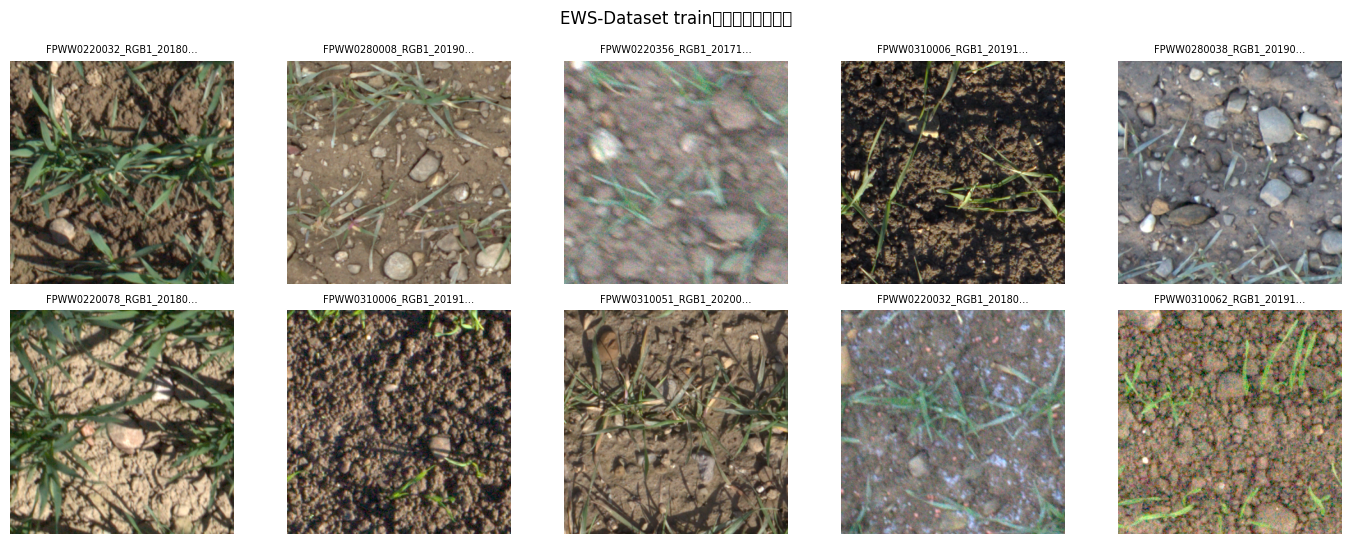

文件名                                                      宽     高        亮度Y       饱和度S
----------------------------------------------------------------------------------------
FPWW0220032_RGB1_20180406_110138_6.png                 350   350     0.3417     0.3364
FPWW0280008_RGB1_20190222_131901_6.png                 350   350     0.4847     0.2677
FPWW0220356_RGB1_20171213_143142_6.png                 350   350     0.5380     0.1438
FPWW0310006_RGB1_20191206_141944_6.png                 350   350     0.2417     0.2937
FPWW0280038_RGB1_20190213_172544_6.png                 350   350     0.4878     0.0955
FPWW0220078_RGB1_20180411_114840_6.png                 350   350     0.4609     0.3155
FPWW0310006_RGB1_20191104_094342_6.png                 350   350     0.3338     0.3460
FPWW0310051_RGB1_20200224_131726_6.png                 350   350     0.4065     0.2957
FPWW0220032_RGB1_20180207_120354_6.png                 350   350     0.4852     0.1417
FPWW0310062_RGB1_20191104_092756_6.png   

In [4]:
from PIL import Image


def find_ews_train_dir(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        d = p / "EWS" / "data" / "EWS-Dataset" / "train"
        if d.is_dir():
            return d
    raise FileNotFoundError("未找到 EWS/data/EWS-Dataset/train")


EWS_TRAIN_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\EWS-Dataset\train")
if not EWS_TRAIN_DIR.is_dir():
    EWS_TRAIN_DIR = find_ews_train_dir()
print("EWS_TRAIN_DIR:", EWS_TRAIN_DIR)


def list_ews_rgb_pngs(train_dir: Path) -> list[Path]:
    out: list[Path] = []
    for p in sorted(train_dir.glob("*.png")):
        if p.name.endswith("_mask.png"):
            continue
        if not p.with_name(p.stem + "_mask.png").is_file():
            raise FileNotFoundError(f"缺少配对标注: {p.name}")
        out.append(p)
    if not out:
        raise FileNotFoundError(f"未找到 RGB PNG: {train_dir}")
    return out


def rgb_u8_to_f32(rgb: np.ndarray) -> np.ndarray:
    return rgb.astype(np.float32) / 255.0


def mean_brightness_saturation(img_f: np.ndarray) -> tuple[float, float]:
    """img_f: (H, W, 3), float32,约 [0, 1]。"""
    r = img_f[..., 0]
    g = img_f[..., 1]
    b = img_f[..., 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    mx = np.maximum(np.maximum(r, g), b)
    mn = np.minimum(np.minimum(r, g), b)
    sat = np.zeros_like(mx, dtype=np.float32)
    ok = mx > 1e-8
    sat[ok] = (mx[ok] - mn[ok]) / mx[ok]
    return float(np.mean(y)), float(np.mean(sat))


N_EWS = 10
SEED_EWS = 43
rng_ews = random.Random(SEED_EWS)
ews_paths = list_ews_rgb_pngs(EWS_TRAIN_DIR)
sel_ews = pick_paths(ews_paths, N_EWS, rng_ews)

rows: list[tuple[str, int, int, float, float]] = []
fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
for ax, pth in zip(np.ravel(axes), sel_ews):
    im = Image.open(pth).convert("RGB")
    arr_u8 = np.asarray(im)
    br, sat = mean_brightness_saturation(rgb_u8_to_f32(arr_u8))
    rows.append((pth.name, im.width, im.height, br, sat))
    ax.imshow(arr_u8)
    ax.set_title(pth.stem[:22] + ("…" if len(pth.stem) > 22 else ""), fontsize=7)
    ax.axis("off")

plt.suptitle("EWS-Dataset train：原图（无蒙层）", fontsize=12)
plt.tight_layout()
plt.show()

print(f"{'文件名':<52} {'宽':>5} {'高':>5} {'亮度Y':>10} {'饱和度S':>10}")
print("-" * 88)
for name, w, h, br, sat in rows:
    print(f"{name:<52} {w:5d} {h:5d} {br:10.4f} {sat:10.4f}")

### Sugar-Beets `img_350_crop`：亮度 / 饱和度统计

对裁边并缩放后的 **350×350** PNG（`rgb_*.png`）逐张计算与上文相同的 **亮度 Y**、**饱和度 S**（全像素均值），并输出每张图的统计量及整体汇总。默认目录为 `D:\Cursor\UNSW-COMP-9517\...\ds\img_350_crop`。

In [2]:
from pathlib import Path

import numpy as np
from PIL import Image

CROP350_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop")


def _rgb_u8_to_f32(rgb: np.ndarray) -> np.ndarray:
    return rgb.astype(np.float32) / 255.0


def _mean_brightness_saturation(img_f: np.ndarray) -> tuple[float, float]:
    r = img_f[..., 0]
    g = img_f[..., 1]
    b = img_f[..., 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    mx = np.maximum(np.maximum(r, g), b)
    mn = np.minimum(np.minimum(r, g), b)
    sat = np.zeros_like(mx, dtype=np.float32)
    ok = mx > 1e-8
    sat[ok] = (mx[ok] - mn[ok]) / mx[ok]
    return float(np.mean(y)), float(np.mean(sat))


if not CROP350_DIR.is_dir():
    raise FileNotFoundError(f"目录不存在: {CROP350_DIR}")

crop_paths = sorted(CROP350_DIR.glob("rgb_*.png"))
if not crop_paths:
    raise FileNotFoundError(f"未找到 rgb_*.png: {CROP350_DIR}")

rows_bs: list[tuple[str, float, float]] = []
try:
    from tqdm import tqdm as _tqdm
except ImportError:
    _tqdm = None

_iter = _tqdm(crop_paths, desc="img_350_crop") if _tqdm else crop_paths
for pth in _iter:
    im = Image.open(pth).convert("RGB")
    if im.size != (350, 350):
        raise ValueError(f"期望350×350，得到 {im.size[0]}×{im.size[1]}: {pth.name}")
    br, sat = _mean_brightness_saturation(_rgb_u8_to_f32(np.asarray(im)))
    rows_bs.append((pth.name, br, sat))

br_all = np.array([r[1] for r in rows_bs], dtype=np.float64)
sat_all = np.array([r[2] for r in rows_bs], dtype=np.float64)

print(f"目录: {CROP350_DIR}")
print(f"张数: {len(rows_bs)}")
print(
 f"亮度 Y — 均值 {br_all.mean():.4f}  标准差 {br_all.std():.4f}  最小 {br_all.min():.4f}  最大 {br_all.max():.4f}"
)
print(
    f"饱和度 S — 均值 {sat_all.mean():.4f}  标准差 {sat_all.std():.4f}  最小 {sat_all.min():.4f}  最大 {sat_all.max():.4f}"
)
print("\n前 10 张（可按需改为抽样展示）:")
print(f"{'文件名':<42} {'亮度Y':>10} {'饱和度S':>10}")
print("-" * 64)
for name, br, sat in rows_bs[:10]:
    print(f"{name:<42} {br:10.4f} {sat:10.4f}")

img_350_crop: 100%|██████████| 12714/12714 [01:24<00:00, 150.29it/s]

目录: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop
张数: 12714
亮度 Y — 均值 0.1748  标准差 0.0540  最小 0.0967  最大 0.2891
饱和度 S — 均值 0.3436  标准差 0.0295  最小 0.2214  最大 0.4088

前 10 张（可按需改为抽样展示）:
文件名                                               亮度Y       饱和度S
----------------------------------------------------------------
rgb_1461246987_538570251.png                   0.1762     0.2872
rgb_1461246988_538516501.png                   0.1763     0.2870
rgb_1461246989_538553225.png                   0.1763     0.2867
rgb_1461246990_538819164.png                   0.1764     0.2875
rgb_1461246991_538568782.png                   0.1765     0.2874
rgb_1461246992_538618413.png                   0.1764     0.2875
rgb_1461246993_538626440.png                   0.1765     0.2873
rgb_1461246994_538598325.png                   0.1765     0.2873
rgb_1461246995_538652193.png                   0.1764     0.2876
rgb_1461246996_538682885.png                   0.1762     0.2873


### `img_350_crop` → 匹配 EWS `train` 亮度并展示

用 **EWS-Dataset `train` 全部原图** 的平均 **BT.601 亮度 Y** 作为目标 `Y_target`。对从 `img_350_crop` 随机抽取的 **10** 张图，按 **整体增益** `s = Y_target / \bar{Y}` 缩放 RGB（`float32 [0,1]`），再 `clip` 到 `[0,1]`，使整图平均亮度逼近 EWS；**色相大致保留**，极亮处可能因裁顶而略压对比。

下方代码格自包含；运行前需已安装 `matplotlib`。

EWS train 共 142 张，逐张平均亮度再取平均 → Y_target = 0.3974


C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 20142 (\N{CJK UNIFIED IDEOGRAPH-4EAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 21305 (\N{CJK UNIFIED IDEOGRAPH-5339}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_19084\3326222954.py:104: UserWarning: Glyph 37

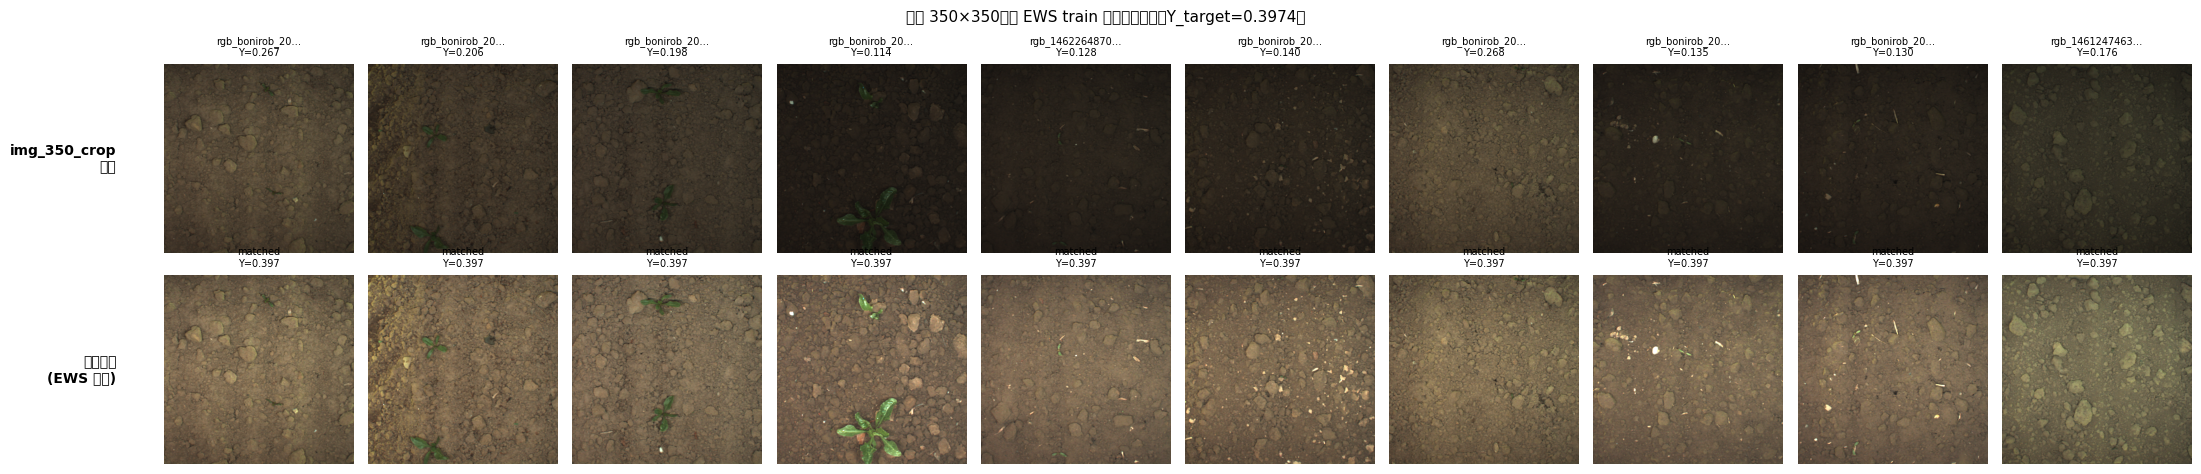

文件名                                           Y原图      Y 匹配后     增益 s
----------------------------------------------------------------------
rgb_bonirob_2016-05-06-11-21-29_10_frame304.png   0.2670     0.3974    1.489
rgb_bonirob_2016-05-10-11-39-31_15_frame74.png   0.2057     0.3974    1.932
rgb_bonirob_2016-05-12-10-26-12_6_frame138.png   0.1980     0.3974    2.007
rgb_bonirob_2016-05-23-11-02-39_5_frame134.png   0.1143     0.3971    3.475
rgb_1462264870_678303224.png               0.1280     0.3973    3.105
rgb_bonirob_2016-04-27-14-19-42_2_frame4.png   0.1399     0.3973    2.841
rgb_bonirob_2016-05-05-13-20-54_20_frame166.png   0.2678     0.3974    1.484
rgb_bonirob_2016-04-28-12-20-29_6_frame240.png   0.1346     0.3969    2.952
rgb_bonirob_2016-05-03-11-16-33_2_frame370.png   0.1304     0.3971    3.047
rgb_1461247463_545382715.png               0.1760     0.3974    2.258


In [3]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

EWS_TRAIN_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\EWS-Dataset\train")
CROP350_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop")
N_SAMPLES = 10
SEED_MATCH = 44


def _rgb_u8_to_f32(a: np.ndarray) -> np.ndarray:
    return a.astype(np.float32) / 255.0


def _mean_luma_bt601(rgb_f: np.ndarray) -> float:
    r = rgb_f[..., 0]
    g = rgb_f[..., 1]
    b = rgb_f[..., 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    return float(np.mean(y))


def _match_mean_luma(rgb_f: np.ndarray, y_target: float) -> np.ndarray:
    y_m = _mean_luma_bt601(rgb_f)
    s = y_target / (y_m + 1e-8)
    return np.clip(rgb_f * s, 0.0, 1.0)


def _list_ews_rgb(train_dir: Path) -> list[Path]:
    out: list[Path] = []
    for p in sorted(train_dir.glob("*.png")):
        if p.name.endswith("_mask.png"):
            continue
        if not p.with_name(p.stem + "_mask.png").is_file():
            continue
        out.append(p)
    return out


ews_rgb = _list_ews_rgb(EWS_TRAIN_DIR)
if not ews_rgb:
    raise FileNotFoundError(f"未找到 EWS RGB: {EWS_TRAIN_DIR}")

y_ews_per_image = []
for p in ews_rgb:
    im = Image.open(p).convert("RGB")
    y_ews_per_image.append(_mean_luma_bt601(_rgb_u8_to_f32(np.asarray(im))))
Y_TARGET = float(np.mean(y_ews_per_image))
print(f"EWS train 共 {len(ews_rgb)} 张，逐张平均亮度再取平均 → Y_target = {Y_TARGET:.4f}")

crop_all = sorted(CROP350_DIR.glob("rgb_*.png"))
if len(crop_all) < N_SAMPLES:
    raise FileNotFoundError(f"{CROP350_DIR} 中 rgb_*.png 不足 {N_SAMPLES} 张")

rng_m = random.Random(SEED_MATCH)
sel_crop = rng_m.sample(crop_all, N_SAMPLES)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(2.2 * N_SAMPLES, 4.8))
for j, pth in enumerate(sel_crop):
    im = Image.open(pth).convert("RGB")
    if im.size != (350, 350):
        raise ValueError(im.size)
    rgb0 = _rgb_u8_to_f32(np.asarray(im))
    y0 = _mean_luma_bt601(rgb0)
    rgb1 = _match_mean_luma(rgb0, Y_TARGET)
    y1 = _mean_luma_bt601(rgb1)

    ax0, ax1 = axes[0, j], axes[1, j]
    ax0.imshow(rgb0, vmin=0, vmax=1)
    ax0.set_title(f"{pth.stem[:14]}…\nY={y0:.3f}", fontsize=7)
    ax0.axis("off")
    ax1.imshow(rgb1, vmin=0, vmax=1)
    ax1.set_title(f"matched\nY={y1:.3f}", fontsize=7)
    ax1.axis("off")

axes[0, 0].text(
    -0.25,
    0.5,
    "img_350_crop\n原图",
    transform=axes[0, 0].transAxes,
    fontsize=10,
    fontweight="bold",
    va="center",
    ha="right",
)
axes[1, 0].text(
    -0.25,
    0.5,
    "亮度匹配\n(EWS 均值)",
    transform=axes[1, 0].transAxes,
    fontsize=10,
    fontweight="bold",
    va="center",
    ha="right",
)

plt.suptitle(
    f"甜菜 350×350：按 EWS train 平均亮度对齐（Y_target={Y_TARGET:.4f}）",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"{'文件名':<40} {'Y原图':>8} {'Y 匹配后':>10} {'增益 s':>8}")
print("-" * 70)
for pth in sel_crop:
    im = Image.open(pth).convert("RGB")
    rgb0 = _rgb_u8_to_f32(np.asarray(im))
    y0 = _mean_luma_bt601(rgb0)
    rgb1 = _match_mean_luma(rgb0, Y_TARGET)
    y1 = _mean_luma_bt601(rgb1)
    s = Y_TARGET / (y0 + 1e-8)
    print(f"{pth.name:<40} {y0:8.4f} {y1:10.4f} {s:8.3f}")

### 批量：整目录 `img_350_crop` 按 EWS train 平均亮度对齐

将 **`img_350_crop`** 下全部 `rgb_*.png` 用与上一格相同的 **`s = Y_target / mean(Y)`** 处理，写入并列目录 **`img_350_crop_ews_y`**（自动创建）。约1.2 万张时运行需一两分钟，视磁盘而定。

In [ ]:
from pathlib import Path

import numpy as np
from PIL import Image

EWS_TRAIN_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\EWS-Dataset\train")
CROP350_DIR = Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop")
OUT_CROP350_EWS_Y = CROP350_DIR.parent / "img_350_crop_ews_y"


def _rgb_u8_to_f32(a: np.ndarray) -> np.ndarray:
    return a.astype(np.float32) / 255.0


def _mean_luma_bt601(rgb_f: np.ndarray) -> float:
    r = rgb_f[..., 0]
    g = rgb_f[..., 1]
    b = rgb_f[..., 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    return float(np.mean(y))


def _match_mean_luma(rgb_f: np.ndarray, y_target: float) -> np.ndarray:
    y_m = _mean_luma_bt601(rgb_f)
    s = y_target / (y_m + 1e-8)
    return np.clip(rgb_f * s, 0.0, 1.0)


def _list_ews_rgb(train_dir: Path) -> list[Path]:
    out: list[Path] = []
    for p in sorted(train_dir.glob("*.png")):
        if p.name.endswith("_mask.png"):
            continue
        if not p.with_name(p.stem + "_mask.png").is_file():
            continue
        out.append(p)
    return out


OUT_CROP350_EWS_Y.mkdir(parents=True, exist_ok=True)

ews_rgb = _list_ews_rgb(EWS_TRAIN_DIR)
if not ews_rgb:
    raise FileNotFoundError(f"未找到 EWS RGB: {EWS_TRAIN_DIR}")

y_ews_per_image = []
for p in ews_rgb:
    im = Image.open(p).convert("RGB")
    y_ews_per_image.append(_mean_luma_bt601(_rgb_u8_to_f32(np.asarray(im))))
Y_TARGET = float(np.mean(y_ews_per_image))
print(f"Y_target（EWS train 逐张亮度再平均）= {Y_TARGET:.4f}")

crop_paths = sorted(CROP350_DIR.glob("rgb_*.png"))
if not crop_paths:
    raise FileNotFoundError(f"未找到 rgb_*.png: {CROP350_DIR}")

try:
    from tqdm import tqdm as _tqdm_b
except ImportError:
    _tqdm_b = None

_iter_b = _tqdm_b(crop_paths, desc="img_350_crop → ews_y") if _tqdm_b else crop_paths

n_ok = 0
for pth in _iter_b:
    im = Image.open(pth).convert("RGB")
    if im.size != (350, 350):
        raise ValueError(f"期望 350×350: {pth.name} → {im.size}")
    rgb0 = _rgb_u8_to_f32(np.asarray(im))
    rgb1 = _match_mean_luma(rgb0, Y_TARGET)
    out_u8 = np.clip(np.round(rgb1 * 255.0), 0, 255).astype(np.uint8)
    out_path = OUT_CROP350_EWS_Y / pth.name
    Image.fromarray(out_u8, mode="RGB").save(out_path, format="PNG", optimize=True)
    n_ok += 1

print(f"完成: {n_ok} 张 → {OUT_CROP350_EWS_Y}")